# CH2/CH4 imaging analysis

Loads and displays microscopy channels from a folder-based dataset where only two channels are available as TIFF images:
- **CH2 = Blue**
- **CH4 = Red**

The notebook also computes **Red/Blue** and **Blue/Red** intensity ratios inside a blue-thresholded cell mask.

In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE_DIR = Path("/Users/bisot/Downloads/wetransfer_pdot-cropped-images_2026-06-02_1732")

CHANNEL_LABELS = {2: "Blue", 4: "Red"}
CHANNEL_COLORS = {2: "#4488ff", 4: "#ff4444"}

def list_folders():
    return sorted([p for p in BASE_DIR.iterdir() if p.is_dir()], key=lambda p: p.name)

def get_available_channels(folder_path: Path):
    """Return sorted list of available channel numbers from Image_CH*.tif files."""
    channels = []
    for p in sorted(folder_path.glob("Image_CH*.tif")):
        try:
            channels.append(int(p.stem.split("CH")[-1]))
        except ValueError:
            continue
    return sorted(channels)

def _normalize_for_display(img: np.ndarray) -> np.ndarray:
    lo, hi = np.percentile(img, [1, 99])
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    return np.clip((img - lo) / (hi - lo), 0, 1).astype(np.float32)

def show_channel(folder_name: str, channel: int | str):
    """Display one channel (2 or 4) or an overlay."""
    folder_path = BASE_DIR / folder_name
    if not folder_path.exists():
        raise FileNotFoundError(f"Folder not found: {folder_path}")

    available = get_available_channels(folder_path)

    if str(channel).lower() == "overlay":
        if not {2, 4}.issubset(set(available)):
            raise ValueError(f"CH2 and CH4 are required for overlay in {folder_name}")

        blue = mpimg.imread(folder_path / "Image_CH2.tif").astype(np.float32)
        red = mpimg.imread(folder_path / "Image_CH4.tif").astype(np.float32)
        if blue.ndim == 3:
            blue = blue.mean(axis=2)
        if red.ndim == 3:
            red = red.mean(axis=2)

        blue_n = _normalize_for_display(blue)
        red_n = _normalize_for_display(red)
        rgb = np.stack([red_n, np.zeros_like(red_n), blue_n], axis=2)

        fig, ax = plt.subplots(figsize=(7, 7))
        ax.imshow(np.clip(rgb, 0, 1))
        ax.set_title(f"{folder_name}  —  Red/Blue overlay", fontsize=13)
        ax.axis("off")
        plt.tight_layout()
        plt.show()
        return

    ch = int(channel)
    if ch not in available:
        raise ValueError(f"Channel CH{ch} not found in {folder_name}. Available: {available}")

    img_path = folder_path / f"Image_CH{ch}.tif"
    img = mpimg.imread(img_path)
    cmap = "Blues" if ch == 2 else "Reds" if ch == 4 else None

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img, cmap=cmap)
    ax.set_title(f"{folder_name}  —  CH{ch}: {CHANNEL_LABELS.get(ch, 'Unknown')}", fontsize=13, color=CHANNEL_COLORS.get(ch, "black"))
    ax.axis("off")
    plt.tight_layout()
    plt.show()

def show_all_channels(folder_name: str):
    """Display available channels and an overlay side by side."""
    folder_path = BASE_DIR / folder_name
    available = get_available_channels(folder_path)

    panel_items = available + (["overlay"] if {2, 4}.issubset(set(available)) else [])
    fig, axes = plt.subplots(1, len(panel_items), figsize=(4 * len(panel_items), 4))
    if len(panel_items) == 1:
        axes = [axes]
    fig.suptitle(folder_name, fontsize=14)

    for ax, item in zip(axes, panel_items):
        if item == "overlay":
            blue = mpimg.imread(folder_path / "Image_CH2.tif").astype(np.float32)
            red = mpimg.imread(folder_path / "Image_CH4.tif").astype(np.float32)
            if blue.ndim == 3:
                blue = blue.mean(axis=2)
            if red.ndim == 3:
                red = red.mean(axis=2)
            blue_n = _normalize_for_display(blue)
            red_n = _normalize_for_display(red)
            rgb = np.stack([red_n, np.zeros_like(red_n), blue_n], axis=2)
            ax.imshow(np.clip(rgb, 0, 1))
            ax.set_title("Overlay (R/B)", fontsize=11)
            ax.axis("off")
        else:
            ch = int(item)
            img = mpimg.imread(folder_path / f"Image_CH{ch}.tif")
            cmap = "Blues" if ch == 2 else "Reds" if ch == 4 else None
            ax.imshow(img, cmap=cmap)
            ax.set_title(f"CH{ch}: {CHANNEL_LABELS.get(ch, 'Unknown')}", fontsize=11, color=CHANNEL_COLORS.get(ch, "black"))
            ax.axis("off")

    plt.tight_layout()
    plt.show()

print(f"Found {len(list_folders())} folders in {BASE_DIR.name}")

Found 78 folders in wetransfer_pdot-cropped-images_2026-06-02_1732


## Browse available folders

In [18]:
for i, f in enumerate(list_folders()):
    available = get_available_channels(f)
    print(f"[{i:3d}]  {f.name:<30}  (CH: {available})")

[  0]  GAS50 PBMC 1.1                  (CH: [2, 4])
[  1]  GAS50 PBMC 1.2                  (CH: [2, 4])
[  2]  GAS50 PBMC 1.3                  (CH: [2, 4])
[  3]  GAS50 PBMC 2.1                  (CH: [1, 2, 4])
[  4]  GAS50 PBMC 2.2                  (CH: [2, 4])
[  5]  GAS50 PBMC 2.3                  (CH: [2, 4])
[  6]  GAS50 PBMC 3.1                  (CH: [2, 4])
[  7]  GAS50 PBMC 3.2                  (CH: [2, 4])
[  8]  GAS50 PBMC 3.3                  (CH: [2, 4])
[  9]  IFNg Chip 5_1.1                 (CH: [2, 4])
[ 10]  IFNg Chip 5_1.2                 (CH: [2, 4])
[ 11]  IFNg Chip 5_1.3                 (CH: [2, 4])
[ 12]  IFNg Chip 5_2.1                 (CH: [2, 4])
[ 13]  IFNg Chip 5_2.2                 (CH: [2, 4])
[ 14]  IFNg Chip 5_2.3                 (CH: [2, 4])
[ 15]  IFNg Chip 5_3.1                 (CH: [2, 4])
[ 16]  IFNg Chip 5_3.2                 (CH: [2, 4])
[ 17]  IFNg Chip 5_3.3                 (CH: [2, 4])
[ 18]  IFNg Chip 6_1.1                 (CH: [2, 4])
[ 19]  IF

In [19]:
[(f.name, get_available_channels(f)) for f in list_folders()]

[('GAS50 PBMC 1.1', [2, 4]),
 ('GAS50 PBMC 1.2', [2, 4]),
 ('GAS50 PBMC 1.3', [2, 4]),
 ('GAS50 PBMC 2.1', [1, 2, 4]),
 ('GAS50 PBMC 2.2', [2, 4]),
 ('GAS50 PBMC 2.3', [2, 4]),
 ('GAS50 PBMC 3.1', [2, 4]),
 ('GAS50 PBMC 3.2', [2, 4]),
 ('GAS50 PBMC 3.3', [2, 4]),
 ('IFNg Chip 5_1.1', [2, 4]),
 ('IFNg Chip 5_1.2', [2, 4]),
 ('IFNg Chip 5_1.3', [2, 4]),
 ('IFNg Chip 5_2.1', [2, 4]),
 ('IFNg Chip 5_2.2', [2, 4]),
 ('IFNg Chip 5_2.3', [2, 4]),
 ('IFNg Chip 5_3.1', [2, 4]),
 ('IFNg Chip 5_3.2', [2, 4]),
 ('IFNg Chip 5_3.3', [2, 4]),
 ('IFNg Chip 6_1.1', [2, 4]),
 ('IFNg Chip 6_1.2', [2, 4]),
 ('IFNg Chip 6_1.3', [2, 4]),
 ('IFNg Chip 6_2.1', [2, 4]),
 ('IFNg Chip 6_2.3', [2, 4]),
 ('IFNg Chip 6_3', [2, 4]),
 ('IFNg Chip 6_3.1', [2, 4]),
 ('IFNg Chip 6_3.2', [2, 4]),
 ('IFNg Chip 6_3.3', [2, 4]),
 ('IFNg Chip 7_1.1', [2, 4]),
 ('IFNg Chip 7_1.2', [2, 4]),
 ('IFNg Chip 7_1.3', [2, 4]),
 ('IFNg Chip 7_2.1', [2, 4]),
 ('IFNg Chip 7_2.2', [2, 4]),
 ('IFNg Chip 7_2.3', [2, 4]),
 ('IFNg Chip 7_3.1

## View a single channel

Use `show_channel(folder_name, channel)` where `channel` is `2`, `4`, or `"overlay"`.

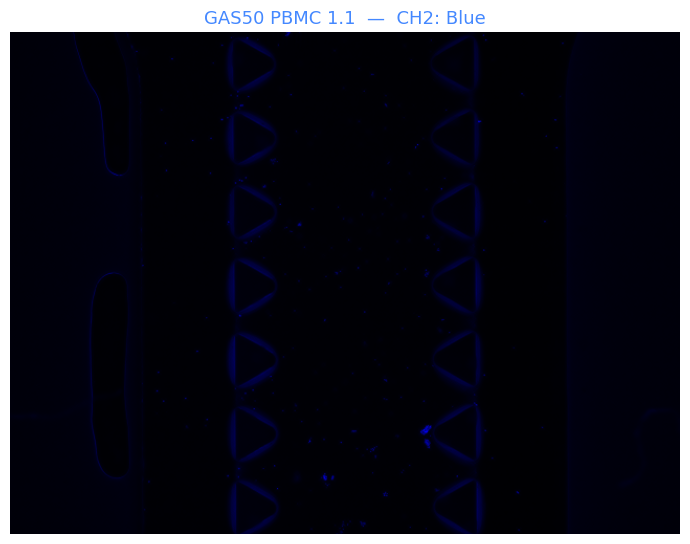

In [20]:
# Show the blue channel from the first folder available
show_channel(list_folders()[0].name, channel=2)

## View all channels at once

Use `show_all_channels(folder_name)` to see both channels (Blue, Red) and their overlay side by side.

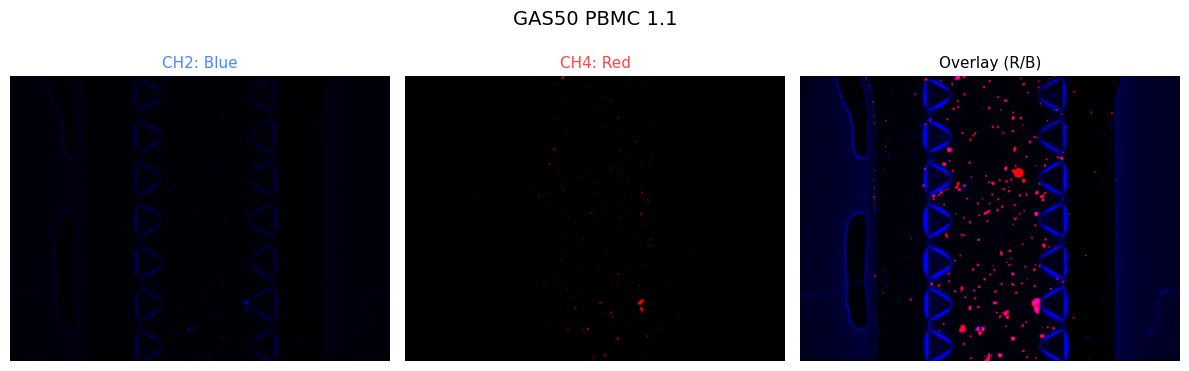

In [21]:
show_all_channels(list_folders()[0].name)

---
## Quantitative analysis — Blue vs Red ratios

**Strategy**
1. Load the Blue channel (CH2, all cells) and threshold it with Otsu to obtain a **cell mask**.
2. Within that mask, compute the **mean fluorescence** of Red (CH4) relative to Blue (CH2).
3. Report both **Red/Blue** and **Blue/Red** ratios per folder and visualize them.

In [162]:
from skimage import filters, morphology, measure
from scipy.ndimage import binary_fill_holes
import pandas as pd

def load_channel_gray(folder_path: Path, ch: int) -> np.ndarray:
    """Load a channel image as float32 grayscale (mean of RGB)."""
    img = mpimg.imread(folder_path / f"Image_CH{ch}.tif").astype(np.float32)
    if img.ndim == 3:  # RGB
        img = img.mean(axis=2)
    return img

def remove_triangle_artifacts(mask: np.ndarray,
                               size_min: int = 80, size_max: int = 2000,
                            circularity_hi: float = 0.5,
                               solidity_hi: float = 0.50) -> np.ndarray:
    """
    Remove equilateral-triangle-shaped artifacts from a binary mask.

    Strategy:
      1. Close gaps and fill hollows so partial triangle outlines become solid.
      2. Label connected components and compute shape descriptors.
      3. Flag regions whose circularity and solidity match an equilateral triangle:
           - circularity = 4π·area / perimeter²  ≈ 0.605
           - solidity    = area / convex_hull_area ≈ 1.0 (convex shape)
      4. Remove those pixels from the original mask.
    """
    mask = mask.copy()
    # Close gaps then fill so hollow triangle outlines become solid blobs
    # closed = morphology.closing(mask, morphology.disk(5))
    # filled = binary_fill_holes(closed)
    labeled = measure.label(mask)

    for region in measure.regionprops(labeled):
        area = region.area
        perim = region.perimeter_crofton

        if perim == 0:
            continue
        circularity = 4 * np.pi * area / (perim ** 2)
        solidity = region.solidity

        if  ((circularity <= circularity_hi or solidity <= solidity_hi) and area > size_min) or circularity < 0.:
            minr, minc, maxr, maxc = region.bbox
            mask[minr:maxr, minc:maxc][region.image] = False

    return mask

def segment_blue_mask(blue_img: np.ndarray,
                      min_size: int = 200, max_size: int = None,
                      remove_triangles: bool = True) -> np.ndarray:
    """
    Otsu threshold on the blue channel to get a binary cell mask.
    - Hollow contours are filled first so triangle outlines become solid regions.
    - Objects smaller than min_size or larger than max_size are removed.
    - Triangle-shaped artifacts are optionally removed.
    Returns a boolean mask.
    """
    thresh = filters.threshold_otsu(blue_img)
    mask = blue_img > thresh
    # Fill hollow contours (triangle outlines detected as rings) so they are solid
    # mask = binary_fill_holes(mask)
    # Remove small objects
    if min_size is not None:
        mask = morphology.remove_small_objects(mask, min_size=min_size)
    # Remove large objects
    if max_size is not None:
        labeled = measure.label(mask)
        for region in measure.regionprops(labeled):
            if region.area > max_size:
                mask[labeled == region.label] = False
    # Remove equilateral-triangle artifacts
    if remove_triangles:
        mask = remove_triangle_artifacts(mask)
    return mask

def compute_ratios(folder_name: str, min_size: int = 200, max_size: int = None,
                   remove_triangles: bool = True) -> dict:
    """
    For a folder with CH2 (Blue) and CH4 (Red):
    - Segment cells from the Blue channel (CH2) with size filtering.
    - Compute mean(Red) / mean(Blue) and mean(Blue) / mean(Red) inside the mask.
    """
    folder_path = BASE_DIR / folder_name
    available = get_available_channels(folder_path)

    if 2 not in available or 4 not in available:
        raise ValueError(f"Folder {folder_name} must have both CH2 (Blue) and CH4 (Red)")

    blue = load_channel_gray(folder_path, 2)
    red = load_channel_gray(folder_path, 4)

    mask = segment_blue_mask(blue, min_size=min_size, max_size=max_size,
                              remove_triangles=remove_triangles)

    mean_blue = blue[mask].mean()
    mean_red = red[mask].mean()

    return {
        "folder": folder_name,
        "mean_blue": mean_blue,
        "mean_red": mean_red,
        "red_over_blue": mean_red / mean_blue,
        "blue_over_red": mean_blue / mean_red,
        "mask_fraction": mask.mean(),
    }

# Collect all folders
all_folders = [f.name for f in list_folders()]
print(f"Found {len(all_folders)} folders")

Found 78 folders


### Inspect the segmentation on one example

Check that the Otsu mask correctly captures cells before running on all folders.

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89177/222102716.py:64: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = morphology.remove_small_objects(mask, min_size=min_size)


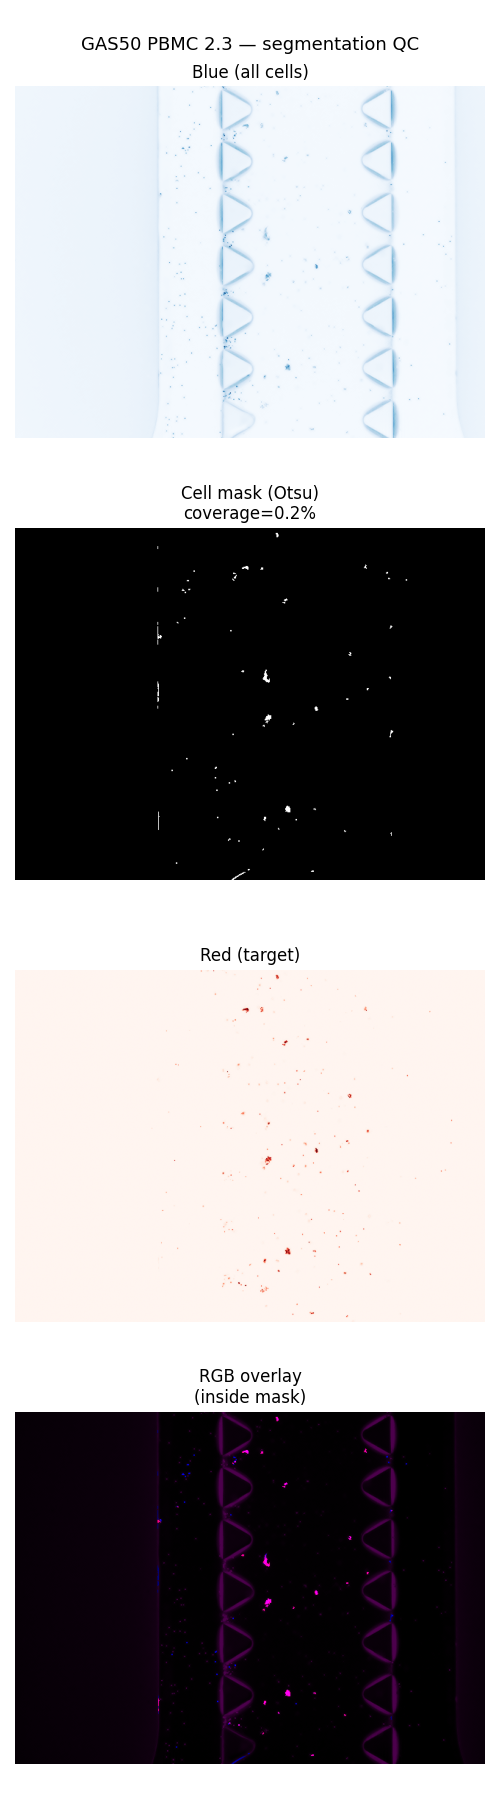

In [164]:
%matplotlib widget
example = all_folders[5] if all_folders else None
if example is None:
    print("No folders found!")
else:
    folder_path = BASE_DIR / example

    blue = load_channel_gray(folder_path, 2)
    red = load_channel_gray(folder_path, 4)
    mask = segment_blue_mask(blue,min_size=3,max_size=1000)

    fig, axes = plt.subplots(4, 1, figsize=(5, 18))
    fig.suptitle(f"{example} — segmentation QC", fontsize=13)

    axes[0].imshow(blue, cmap="Blues")
    axes[0].set_title("Blue (all cells)")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(f"Cell mask (Otsu)\ncoverage={mask.mean():.1%}")
    axes[1].axis("off")

    axes[2].imshow(red, cmap="Reds")
    axes[2].set_title("Red (target)")
    axes[2].axis("off")

    # Overlay: red and blue inside mask
    blue_n = _normalize_for_display(blue)
    red_n = _normalize_for_display(red)
    rgb = np.stack([
        np.where(mask, red_n, blue_n * 0.3),
        np.zeros_like(blue_n),
        np.where(mask, blue_n, blue_n * 0.3),
    ], axis=2)
    axes[3].imshow(np.clip(rgb, 0, 1))
    axes[3].set_title("RGB overlay\n(inside mask)")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

18661 regions collected from 78 folders


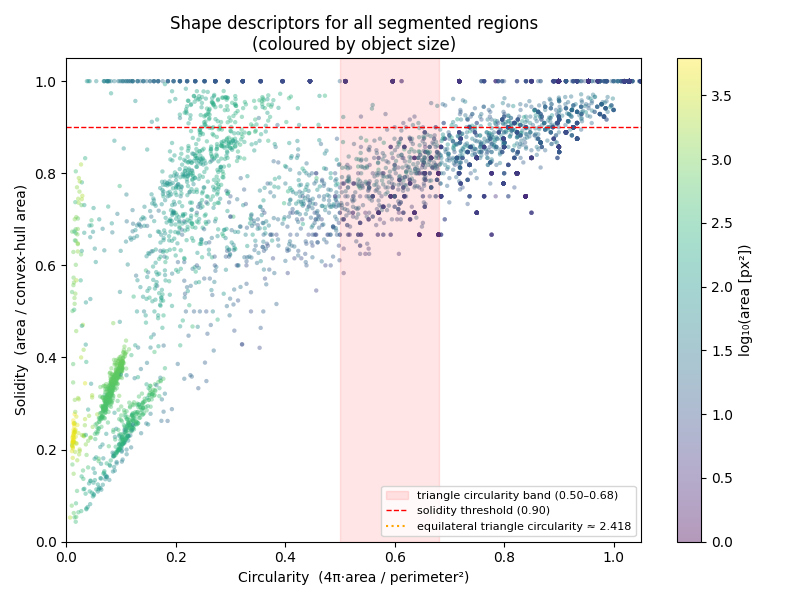

In [165]:

# --- Circularity vs Solidity scatter for ALL regions across all folders ---
# Helps tune the triangle-detection thresholds visually.

records = []
for fname in all_folders:
    fp = BASE_DIR / fname
    try:
        b = load_channel_gray(fp, 2)
        thresh = filters.threshold_otsu(b)
        raw_mask = b > thresh
        closed = raw_mask

        from scipy.ndimage import binary_fill_holes
        # closed = binary_fill_holes(closed)
        labeled = measure.label(closed)
        for region in measure.regionprops(labeled):
            area = region.area
            perim = region.perimeter_crofton

            if perim == 0:
                continue
            circularity = 4 * np.pi * area / (perim ** 2)
            records.append({
                "folder": fname,
                "area": area,
                "circularity": circularity,
                "solidity": region.solidity,
            })
    except Exception as e:
        print(f"⚠ {fname}: {e}")

df_regions = pd.DataFrame(records)
print(f"{len(df_regions)} regions collected from {df_regions['folder'].nunique()} folders")

fig, ax = plt.subplots(figsize=(8, 6))

# colour by log-area
sc = ax.scatter(
    df_regions["circularity"],
    df_regions["solidity"],
    c=np.log10(df_regions["area"].clip(1)),
    cmap="viridis", alpha=0.4, s=10, linewidths=0,
)
plt.colorbar(sc, ax=ax, label="log₁₀(area [px²])")

# Highlight the triangle detection band
ax.axvspan(0.50, 0.68, color="red", alpha=0.10, label="triangle circularity band (0.50–0.68)")
ax.axhline(0.90, color="red", linestyle="--", linewidth=1, label="solidity threshold (0.90)")

# Mark exact equilateral-triangle circularity
ax.axvline(4 * np.pi / 9 * np.sqrt(3), color="orange", linestyle=":", linewidth=1.5,
           label=f"equilateral triangle circularity ≈ {4*np.pi/(9/np.sqrt(3)):.3f}")

ax.set_xlabel("Circularity  (4π·area / perimeter²)")
ax.set_ylabel("Solidity  (area / convex-hull area)")
ax.set_title("Shape descriptors for all segmented regions\n(coloured by object size)")
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
plt.tight_layout()

plt.show()

In [145]:
print(df_regions[df_regions["circularity"] > 1.0])

               folder  area  circularity  solidity
2      GAS50 PBMC 1.1   1.0     1.747627       1.0
3      GAS50 PBMC 1.1   1.0     1.747627       1.0
4      GAS50 PBMC 1.1   1.0     1.747627       1.0
6      GAS50 PBMC 1.1   2.0     1.199382       1.0
8      GAS50 PBMC 1.1   1.0     1.747627       1.0
...               ...   ...          ...       ...
18655  hIgG1 PBMC 3.3   2.0     1.199382       1.0
18656  hIgG1 PBMC 3.3   1.0     1.747627       1.0
18657  hIgG1 PBMC 3.3   2.0     1.199382       1.0
18659  hIgG1 PBMC 3.3   2.0     1.199382       1.0
18660  hIgG1 PBMC 3.3   3.0     1.076275       1.0

[13543 rows x 4 columns]


### Run on all folders and build a results table

In [ ]:
results = []
for folder_name in sorted(all_folders):
    try:
        results.append(compute_ratios(folder_name,min_size=3,max_size=100))
    except Exception as e:
        print(f"⚠  {folder_name}: {e}")

df = pd.DataFrame(results)

# Extract experiment label (e.g. "CH1D2" from "CH1D2_01")
df["experiment"] = df["folder"].str.extract(r"^(.+?)_\d+$").fillna(df["folder"])

df.set_index("folder", inplace=True)
print(f"Total: {len(df)} folders")
print(df.round(3))

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_89177/222102716.py:64: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = morphology.remove_small_objects(mask, min_size=min_size)


Total: 78 folders
                mean_blue   mean_red  red_over_blue  blue_over_red  \
folder                                                               
GAS50 PBMC 1.1  21.702000  25.034000          1.154          0.867   
GAS50 PBMC 1.2  30.525999  34.919998          1.144          0.874   
GAS50 PBMC 1.3  27.299999  29.549999          1.082          0.924   
GAS50 PBMC 2.1  27.118999  38.278999          1.412          0.708   
GAS50 PBMC 2.2  26.082001  33.807999          1.296          0.771   
...                   ...        ...            ...            ...   
hIgG1 PBMC 2.2  26.135000  29.900999          1.144          0.874   
hIgG1 PBMC 2.3  27.136999  41.445000          1.527          0.655   
hIgG1 PBMC 3.1  38.271000  47.110001          1.231          0.812   
hIgG1 PBMC 3.2  19.827000  21.605000          1.090          0.918   
hIgG1 PBMC 3.3  22.077999  22.664000          1.027          0.974   

                mask_fraction      experiment  
folder                 

In [174]:
df.to_csv("blue_red_ratios_analysis.csv")

### Visualise Blue vs Red ratios per folder

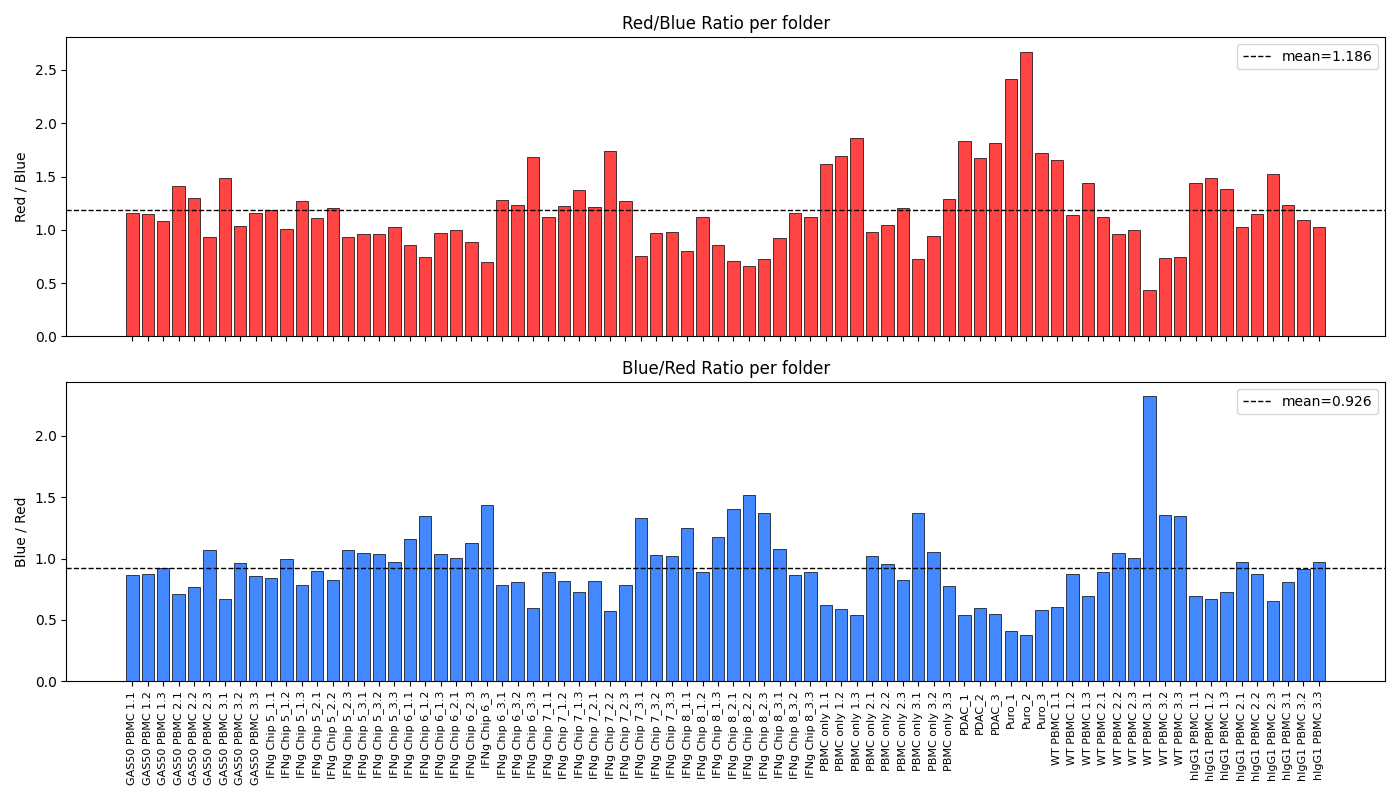

In [175]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x = np.arange(len(df))
labels_x = df.index.tolist()

# Red over Blue
axes[0].bar(x, df["red_over_blue"], color="#ff4444", edgecolor="k", linewidth=0.5)
axes[0].set_ylabel("Red / Blue")
axes[0].set_title("Red/Blue Ratio per folder")
axes[0].axhline(df["red_over_blue"].mean(), color="k", linestyle="--", linewidth=1,
                label=f"mean={df['red_over_blue'].mean():.3f}")
axes[0].legend()

# Blue over Red
axes[1].bar(x, df["blue_over_red"], color="#4488ff", edgecolor="k", linewidth=0.5)
axes[1].set_ylabel("Blue / Red")
axes[1].set_title("Blue/Red Ratio per folder")
axes[1].axhline(df["blue_over_red"].mean(), color="k", linestyle="--", linewidth=1,
                label=f"mean={df['blue_over_red'].mean():.3f}")
axes[1].legend()

plt.xticks(x, labels_x, rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

### Group by experiment (average replicates)


Ratios grouped by experiment:
                red_over_blue_mean  red_over_blue_sem  blue_over_red_mean  \
experiment                                                                  
GAS50 PBMC 1.1              1.1221             0.0335              0.9536   
IFNg Chip 6                 0.6972                NaN              1.4342   
PDAC                        1.7751             0.0522              0.5644   
Puro                        2.2696             0.2851              0.4565   

                blue_over_red_sem  
experiment                         
GAS50 PBMC 1.1             0.0329  
IFNg Chip 6                   NaN  
PDAC                       0.0171  
Puro                       0.0637  


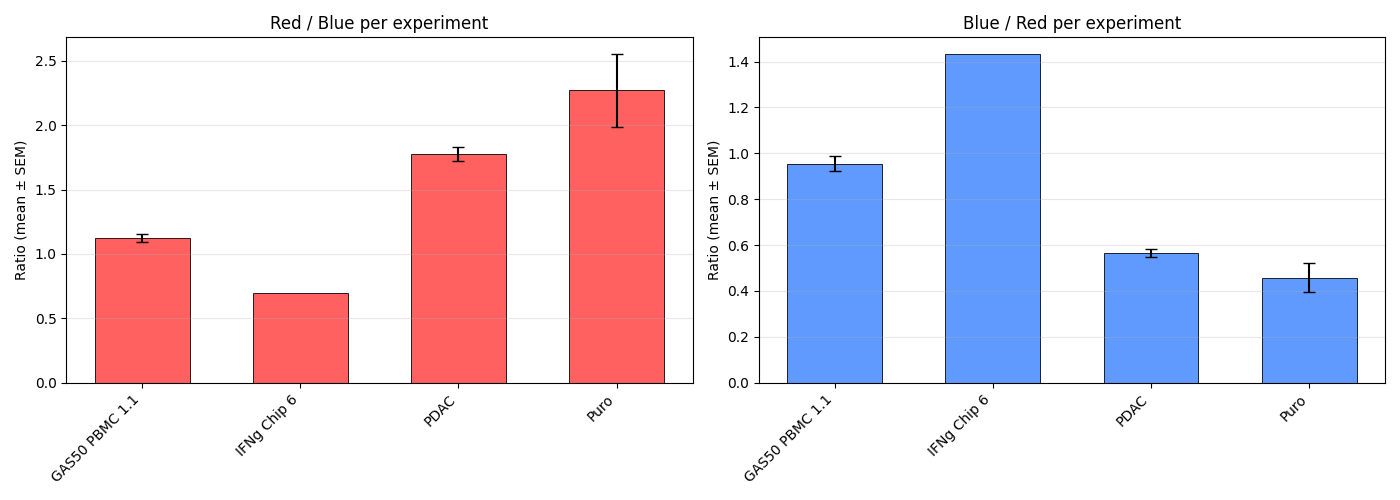

In [176]:
grouped = df.groupby("experiment")[["red_over_blue", "blue_over_red"]].agg(["mean", "sem"])
grouped.columns = ["_".join(c) for c in grouped.columns]
print("\nRatios grouped by experiment:")
print(grouped.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
exps = grouped.index.tolist()
xg = np.arange(len(exps))
width = 0.6

# Red/Blue
means_rb = grouped["red_over_blue_mean"]
sems_rb = grouped["red_over_blue_sem"]
axes[0].bar(xg, means_rb, yerr=sems_rb, color="#ff4444", edgecolor="k", linewidth=0.7,
            capsize=4, alpha=0.85, width=width)
axes[0].set_xticks(xg)
axes[0].set_xticklabels(exps, rotation=45, ha="right", fontsize=10)
axes[0].set_ylabel("Ratio (mean ± SEM)")
axes[0].set_title("Red / Blue per experiment")
axes[0].grid(axis="y", alpha=0.3)

# Blue/Red
means_br = grouped["blue_over_red_mean"]
sems_br = grouped["blue_over_red_sem"]
axes[1].bar(xg, means_br, yerr=sems_br, color="#4488ff", edgecolor="k", linewidth=0.7,
            capsize=4, alpha=0.85, width=width)
axes[1].set_xticks(xg)
axes[1].set_xticklabels(exps, rotation=45, ha="right", fontsize=10)
axes[1].set_ylabel("Ratio (mean ± SEM)")
axes[1].set_title("Blue / Red per experiment")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()